In [1]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
sensors_df

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.000004,0.984199,0.094463,0.000373,0.999849


In [2]:
X = rf_preprocessor.group_and_pad(sensors_df, group_col="Experiment_ID")[:,:,1:]
Y = rf_preprocessor.group_and_pad(target_df, group_col="Experiment_ID")[:,:-1,2:]
X.shape

(100, 1743, 15)

In [3]:
import pandas as pd
import numpy as np

# Make sure 'Time_[s]' is a column
df = sensors_df.reset_index()  # if 'Time_[s]' was the index

def resample_experiment_mean(group, n=46):
    """
    Resample an experiment to n time steps by averaging values in equally spaced bins.
    """
    group = group.sort_values('Time_[s]')  # ensure time is sorted
    num_points = len(group)
    
    # Define bin edges for splitting into n bins
    bin_edges = np.linspace(0, num_points, n + 1, dtype=int)
    
    # Container for resampled data
    resampled = []
    
    for i in range(n):
        start, end = bin_edges[i], bin_edges[i + 1]
        segment = group.iloc[start:end]
        if len(segment) == 0:
            continue
        mean_vals = segment.mean(numeric_only=True)  # take mean of numeric columns
        mean_vals['Experiment_ID'] = group['Experiment_ID'].iloc[0]
        mean_vals['Time_[s]'] = segment['Time_[s]'].mean()  # average time in the bin
        resampled.append(mean_vals)
    
    return pd.DataFrame(resampled)

# Apply to each experiment
df_resampled = df.groupby('Experiment_ID', group_keys=False).apply(resample_experiment_mean, n=46)
df_resampled = df_resampled.reset_index(drop=True)


/tmp/ipykernel_6454/904674282.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resampled = df.groupby('Experiment_ID', group_keys=False).apply(resample_experiment_mean, n=46)


In [4]:
import pandas as pd
import numpy as np

def normalize_experiment(group, n=46):
    if len(group) > n:
        # Just take the first 46 rows
        return group.iloc[:n].copy()
    else:
        # Already 46 rows
        return group.copy()

# Apply to each experiment
df_normalized = target_df.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=47)
df_normalized = df_normalized.reset_index(drop=True)


/tmp/ipykernel_6454/900614170.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalized = target_df.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=47)


In [5]:
count= 2
X = rf_preprocessor.group_and_pad(df_resampled, group_col="Experiment_ID")[:1,:,count:]
Y = rf_preprocessor.group_and_pad(df_normalized, group_col="Experiment_ID")[:1,:-1,1:]

# LIFT

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(Y, dtype=torch.float32)

feature_names = list(sensors_df.columns)[count:]

# --------------------------
# More Complex LSTM Model
# --------------------------
class ComplexLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers, 
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim*2)
        self.fc1 = nn.Linear(hidden_dim*2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out, _ = self.lstm(x)                # (batch, seq_len, hidden_dim*2)
        out = self.layer_norm(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = ComplexLSTM(input_dim=X.shape[-1], hidden_dim=128, output_dim=Y.shape[-1], num_layers=5)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)

# --------------------------
# Training loop
# --------------------------
epochs = 5000
batch_size = 8

for epoch in range(epochs):
    permutation = torch.randperm(x_tensor.size(0))
    epoch_loss = 0
    
    for i in range(0, x_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_tensor[indices], y_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")

print("Training complete!")

Epoch 1/5000, Loss: 0.090630
Epoch 2/5000, Loss: 0.056855
Epoch 3/5000, Loss: 0.024125
Epoch 4/5000, Loss: 0.012717
Epoch 5/5000, Loss: 0.008735
Epoch 6/5000, Loss: 0.010234
Epoch 7/5000, Loss: 0.019556
Epoch 8/5000, Loss: 0.018310
Epoch 9/5000, Loss: 0.016883
Epoch 10/5000, Loss: 0.016085
Epoch 11/5000, Loss: 0.013135
Epoch 12/5000, Loss: 0.012238
Epoch 13/5000, Loss: 0.011588
Epoch 14/5000, Loss: 0.009845
Epoch 15/5000, Loss: 0.007944
Epoch 16/5000, Loss: 0.006770
Epoch 17/5000, Loss: 0.006777
Epoch 18/5000, Loss: 0.008499
Epoch 19/5000, Loss: 0.006064
Epoch 20/5000, Loss: 0.007002
Epoch 21/5000, Loss: 0.007336
Epoch 22/5000, Loss: 0.007275
Epoch 23/5000, Loss: 0.007900
Epoch 24/5000, Loss: 0.008130
Epoch 25/5000, Loss: 0.006753
Epoch 26/5000, Loss: 0.006278
Epoch 27/5000, Loss: 0.005497
Epoch 28/5000, Loss: 0.005154
Epoch 29/5000, Loss: 0.005397
Epoch 30/5000, Loss: 0.004767
Epoch 31/5000, Loss: 0.004057
Epoch 32/5000, Loss: 0.005046
Epoch 33/5000, Loss: 0.005410
Epoch 34/5000, Loss

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import GuidedBackprop, DeepLift, IntegratedGradients, Saliency, InputXGradient
import torch.nn as nn

# --------------------------
# Attribution computation
# --------------------------
def compute_attr(sample_input, output_feature, time_step, method_cls):
    """Compute attributions for a specific output feature and time step."""
    class WrappedModel(nn.Module):
        def __init__(self, base_model, time_step, output_feature):
            super().__init__()
            self.base_model = base_model
            self.time_step = time_step
            self.output_feature = output_feature

        def forward(self, x):
            out = self.base_model(x)
            return out[:, self.time_step, self.output_feature]

    wrapped_model = WrappedModel(model, time_step, output_feature)
    method = method_cls(wrapped_model)
    attr = method.attribute(sample_input)
    
    # Return as (features, time)
    return attr.detach().numpy().reshape(sample_input.shape[1], sample_input.shape[2])

# Map output features to names
n_target = 4
target = range(n_target)
target_features = target_df.columns.to_list()[-n_target:]
output_feature_dict = {f: t for f, t in zip(target, target_features)}

# --------------------------
# Widgets
# --------------------------
sample_selector = widgets.IntSlider(
    value=0, min=0, max=x_tensor.shape[0]-1, step=1, description='Sample'
)

feature_selector = widgets.IntSlider(
    value=0, min=0, max=y_tensor.shape[2]-1, step=1, description='Output Feature'
)

time_selector = widgets.IntSlider(
    value=0, min=0, max=x_tensor.shape[1]-1, step=1, description='Time Step'
)

methods = {
    "GuidedBackprop": GuidedBackprop,
    "DeepLift": DeepLift,
    "IntegratedGradients": IntegratedGradients,
    "Saliency": Saliency,
    "InputXGradient": InputXGradient
}

method_selector = widgets.Dropdown(
    options=list(methods.keys()),
    value=list(methods.keys())[0],
    description='Method'
)

out = widgets.Output()

# --------------------------
# Update plot function
# --------------------------
def update_plot(change):
    sample_idx = sample_selector.value
    output_feature_idx = feature_selector.value
    time_step = time_selector.value
    method_name = method_selector.value

    # Compute attribution
    sample_input = x_tensor[sample_idx:sample_idx+1]
    attr_np = compute_attr(sample_input, output_feature_idx, time_step, methods[method_name])

    # Extract model outputs
    model_output = model(sample_input).detach().numpy()[0]
    target_value = model_output[time_step, output_feature_idx]
    sensor_values = sample_input[0].detach().numpy()

    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

        # 1. Attribution heatmap
        im = axes[0].imshow(attr_np.T, cmap='inferno', aspect='auto')
        axes[0].set_title(f"Attribution Map: {method_name}", fontsize=12)
        axes[0].set_ylabel("Feature")
        axes[0].set_yticks(np.arange(len(feature_names)))
        axes[0].set_yticklabels(feature_names, fontsize=9)
        cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

        # 2. Model output vs true output
        axes[1].plot(model_output[:, output_feature_idx], label='Model Output', color='blue')
        axes[1].plot(Y[sample_idx, :, output_feature_idx], label='True Output', color='orange')
        axes[1].scatter(time_step, target_value, color='red', zorder=5, label='Selected Time Step')
        axes[1].set_ylabel("Target Value")
        axes[1].set_title(f"Model Output: {output_feature_dict[output_feature_idx]}", fontsize=12)
        axes[1].legend(loc='upper left', fontsize=9)

        # 3. Sensor input values
        for i, fname in enumerate(feature_names):
            axes[2].plot(sensor_values[:, i], label=fname)
        axes[2].set_xlabel("Time Step")
        axes[2].set_ylabel("Sensor Value")
        axes[2].set_title("Input Sensor Values", fontsize=12)
        axes[2].legend(loc='upper right', fontsize=8, ncol=2)

        plt.tight_layout()
        plt.show()

# --------------------------
# Link widgets
# --------------------------
for w in [sample_selector, feature_selector, time_selector, method_selector]:
    w.observe(update_plot, names='value')

display(widgets.VBox([sample_selector, feature_selector, time_selector, method_selector, out]))

# Initial plot
update_plot(None)


/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:63: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:63: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/arman/Documents/univrsity/Ma

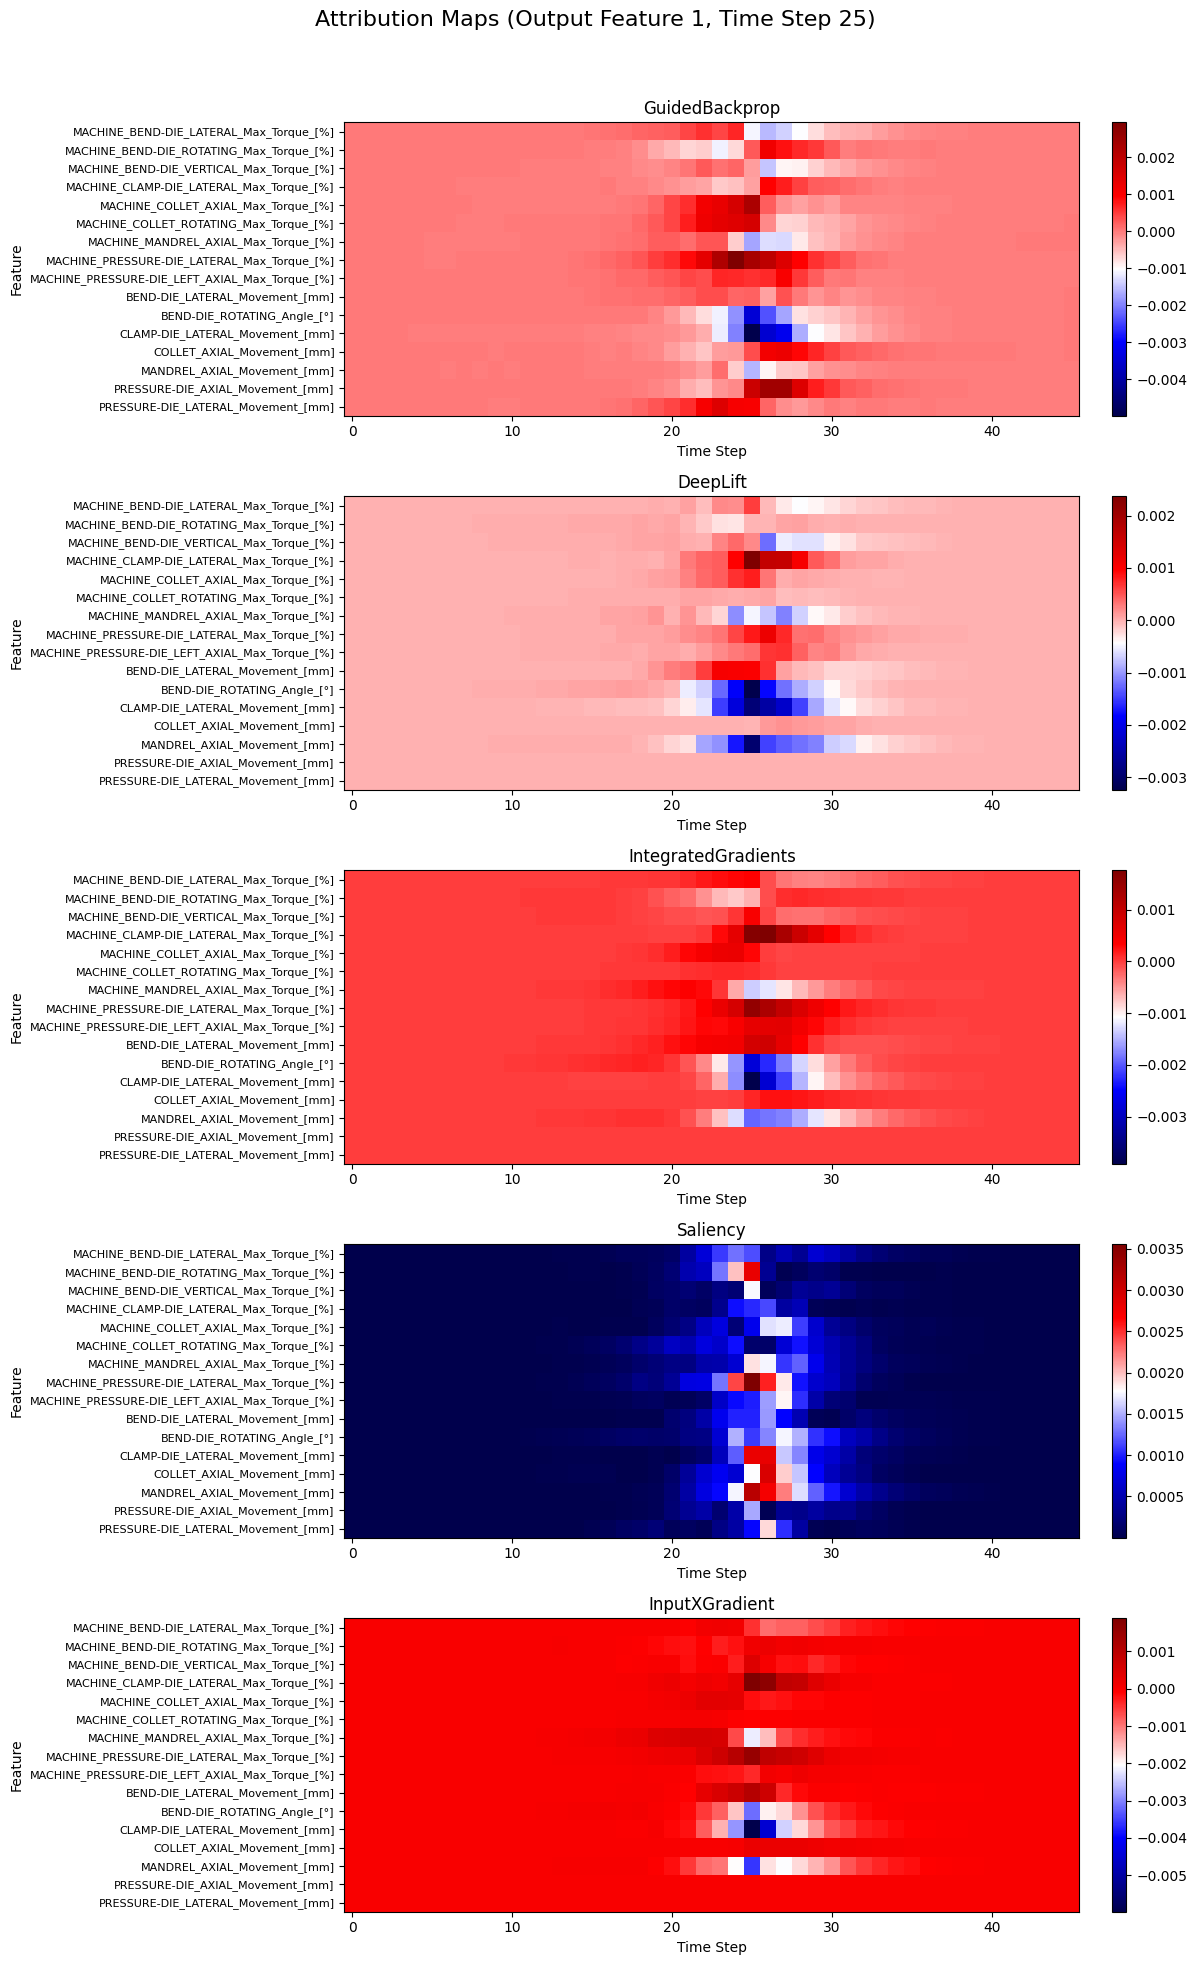

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import GuidedBackprop, DeepLift, IntegratedGradients, Saliency, InputXGradient

# --------------------------
# Pick a sample input to explain
# --------------------------
feature_names = list(sensors_df.columns)[1:]
sample_input = x_tensor[0:1]  # (1,46,16)
target_time_step = 25
target_output_feature = 1

# --------------------------
# Wrap model for scalar output
# --------------------------
class WrappedModel(nn.Module):
    def __init__(self, base_model, time_step, output_feature):
        super().__init__()
        self.base_model = base_model
        self.time_step = time_step
        self.output_feature = output_feature

    def forward(self, x):
        out = self.base_model(x)
        return out[:, self.time_step, self.output_feature]

wrapped_model = WrappedModel(model, target_time_step, target_output_feature)

# --------------------------
# Define attribution methods
# --------------------------
methods = {
    "GuidedBackprop": GuidedBackprop,
    "DeepLift": DeepLift,
    "IntegratedGradients": IntegratedGradients,
    "Saliency": Saliency,
    "InputXGradient": InputXGradient
}

n_methods = len(methods)
fig, axes = plt.subplots(n_methods, 1, figsize=(12, 4 * n_methods))  # vertical stack
axes = axes.flatten() if n_methods > 1 else [axes]

for i, (name, method_cls) in enumerate(methods.items()):
    method = method_cls(wrapped_model)
    attr = method.attribute(sample_input)
    attr_np = attr.detach().numpy().reshape(46, 16)

    im = axes[i].imshow(attr_np.T, cmap='inferno', aspect='auto')
    axes[i].set_title(name)
    axes[i].set_xlabel("Time Step")
    axes[i].set_ylabel("Feature")
    axes[i].set_yticks(np.arange(len(feature_names)))
    axes[i].set_yticklabels(feature_names, fontsize=8)
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle(f"Attribution Maps (Output Feature {target_output_feature}, Time Step {target_time_step})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
import torch as th
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tint.attr import SequentialIntegratedGradients

# --------------------------
# Assume X and Y are your data
# X shape: [num_samples, time_steps, features]
# Y shape: [num_samples, time_steps, all_features]
# --------------------------

# Example: Use first 5 samples
inputs = th.tensor(X[:10,:,:]).float()
X_tensor = th.tensor(X[:10,:,:]).float()
# Select only the outputs you want to predict, one value per output per sample
y_tensor = th.tensor(Y[:10, :, 1]).float()  # last timestep, outputs 1 and 2
batch_size, time_steps, features = X_tensor.shape
num_outputs = y_tensor.shape[1]

# --------------------------
# Define LSTM Regressor
# --------------------------
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)  # map last hidden to multiple outputs

    def forward(self, x):
        out, _ = self.lstm(x)         # [batch, time_steps, hidden_size]
        out = out[:, -1, :]           # take last timestep
        out = self.fc(out)            # [batch, num_outputs]
        return out

hidden_size = 32
mlp = LSTMRegressor(features, hidden_size, num_outputs)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

# --------------------------
# Train LSTM
# --------------------------
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mlp(X_tensor)          # [batch, num_outputs]
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.3217
Epoch [20/100], Loss: 0.2047
Epoch [30/100], Loss: 0.0897
Epoch [40/100], Loss: 0.0313
Epoch [50/100], Loss: 0.0096
Epoch [60/100], Loss: 0.0034
Epoch [70/100], Loss: 0.0010
Epoch [80/100], Loss: 0.0006
Epoch [90/100], Loss: 0.0005
Epoch [100/100], Loss: 0.0005
